In [21]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import LabelEncoder
from sklearn.exceptions import DataConversionWarning
import warnings
warnings.filterwarnings('ignore', category=DataConversionWarning)

In [2]:
DATA_PATH="kalimati_dataset_cleaned.csv"
SPIT_DATE='2023-01-01'

In [26]:
season_map={
    12:0, 1:0,2:0, #winter=0
    3:1, 4:1,5:1, #spring=1
    6:2,7:2,8:2, #summer=2
    9:3,10:3,11:3 #autumn=3
}

In [ ]:
from pathlib import Path

def load_data(path):
    """Load CSV file and return DataFrame. Raises error if file not found."""
    path = Path(path)
    if not path.exists():
        raise FileNotFoundError(f"Data file not found: {path}")
    df = pd.read_csv(path)
    print(f" Loaded {len(df):,} rows from {path.name}")
    return df

In [16]:
def clean_columns(df,cols):
     for col in cols:
          df[col]=df[col].astype(str).str.replace('Rs','').str.replace(',','').str.strip()
          df[col]=pd.to_numeric(df[col],errors='coerce')
          before=len(df)
          df=df.dropna(subset=cols)
          dropped=before-len(df)
          if dropped>0:
               print(f"Dropped {dropped} rows with unparseable prices")
          return df

    

In [17]:
def engineer_features(df):
    df['Date']=pd.to_datetime(df['Date'],format='mixed',dayfirst=False)
    df              = df.sort_values('Date').reset_index(drop=True)
    df['Year']      = df['Date'].dt.year
    df['Month']     = df['Date'].dt.month
    df['Day']       = df['Date'].dt.day
    df['DayOfWeek'] = df['Date'].dt.dayofweek
    df['DayOfYear'] = df['Date'].dt.dayofyear
    df['Quarter']   = df['Date'].dt.quarter
    df['Season']    = df['Month'].map(season_map)
    print(f" Features engineered | Date range: {df['Date'].min().date()} → {df['Date'].max().date()}")
    return df

In [18]:
from sklearn.preprocessing import LabelEncoder
def encode_commodities(df):
    """Label encode commodity names to integers"""
    le = LabelEncoder()
    df['Commodity_Encoded'] = le.fit_transform(df['Commodity'])
    print(f" Encoded {len(le.classes_)} commodities")
    return df, le

In [20]:
def time_based_split(df, split_date):
    """
    Split data by date — train on past, test on future.
    This avoids data leakage (random split can put future dates in training set).
    """
    train = df[df['Date'] < split_date]
    test  = df[df['Date'] >= split_date]
    print(f" Time-based split at {split_date}:")
    print(f"   Train: {len(train):,} rows ({train['Date'].min().date()} → {train['Date'].max().date()})")
    print(f"   Test : {len(test):,} rows  ({test['Date'].min().date()} → {test['Date'].max().date()})")
    return train, test

In [22]:
def evaluate_model(name, y_true, y_pred):
    """Print MAE, RMSE, R² for a model and return metrics"""
    mae  = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2   = r2_score(y_true, y_pred)
    print(f"\n── {name} ──")
    print(f"   MAE  : NPR {mae:.2f}  (average prediction error)")
    print(f"   RMSE : NPR {rmse:.2f}")
    print(f"   R²   : {r2:.4f}  ({r2*100:.1f}% variance explained)")
    return mae, rmse, r2

In [27]:
def predict_commodity(commodity_name, year, month, day, lr, rf, df, le, features):
    """Predict price for a specific commodity and date"""
    if commodity_name not in le.classes_:
        print(f"   '{commodity_name}' not found in dataset")
        return
    comm_encoded = le.transform([commodity_name])[0]
    comm_data    = df[df['Commodity'] == commodity_name]
    avg_min      = comm_data['Min_Price'].mean()
    avg_max      = comm_data['Max_Price'].mean()
    date         = pd.Timestamp(year=year, month=month, day=day)
 
    sample = pd.DataFrame([{
        'Commodity_Encoded': comm_encoded,
        'Year': year, 'Month': month, 'Day': day,
        'DayOfWeek': date.dayofweek,
        'DayOfYear': date.dayofyear,
        'Quarter':   date.quarter,
        'Season':    season_map[month],
        'Min_Price': avg_min,
        'Max_Price': avg_max
    }])
 
    pred_lr = lr.predict(sample)[0]
    pred_rf = rf.predict(sample)[0]
    print(f"\n── SAMPLE PREDICTION ──")
    print(f"   Commodity : {commodity_name}")
    print(f"   Date      : {date.strftime('%B %d, %Y')}")
    print(f"   Linear Regression : NPR {pred_lr:.2f}")
    print(f"   Random Forest     : NPR {pred_rf:.2f}")
 

In [42]:
def plot_results(y_test, y_pred_lr, y_pred_rf, importance_df,
                 r2_lr, mae_lr, r2_rf, mae_rf):
    """Generate and save visualization"""
    fig = plt.figure(figsize=(18, 12))
    gs  = gridspec.GridSpec(2, 3, figure=fig, hspace=0.4, wspace=0.35)
 
    BG    = '#F8F9FA'
    TEXT  = '#1A1A2E'
    GRID  = '#DEE2E6'
    C1    = '#E63946'
    C2    = '#2196F3'
    C3    = '#FF6B35'
    C4    = '#06D6A0'
 
    # Title
    ax0 = fig.add_subplot(gs[0, :])
    ax0.text(0.5, 0.7, 'KALIMATI PRICE PREDICTION',
             ha='center', va='center', fontsize=22, fontweight='bold',
             color=TEXT, transform=ax0.transAxes)
    ax0.text(0.5, 0.2,
             'Time-based split (no data leakage)  |  96,480 Records  |  133 Commodities',
             ha='center', va='center', fontsize=11, color='#888',
             transform=ax0.transAxes)
    ax0.axis('off')
 
    # Actual vs Predicted — LR
    ax1 = fig.add_subplot(gs[1, 0])
    ax1.set_facecolor(BG)
    idx = np.random.choice(len(y_test), min(500, len(y_test)), replace=False)
    ax1.scatter(np.array(y_test)[idx], y_pred_lr[idx], alpha=0.3, s=10, color=C1)
    mv = max(np.array(y_test).max(), y_pred_lr.max())
    ax1.plot([0, mv], [0, mv], 'r--', linewidth=1.5, label='Perfect')
    ax1.set_title(f'Linear Regression\nR²={r2_lr:.3f}  MAE=NPR {mae_lr:.1f}',
                  color=TEXT, fontsize=10, pad=8)
    ax1.set_xlabel('Actual (NPR)', color=TEXT, fontsize=9)
    ax1.set_ylabel('Predicted (NPR)', color=TEXT, fontsize=9)
    ax1.tick_params(colors=TEXT, labelsize=8)
    ax1.spines[['top','right']].set_visible(False)
    for s in ['bottom','left']: ax1.spines[s].set_color(GRID)
    ax1.legend(fontsize=8, facecolor=BG, labelcolor=TEXT)
 
    # Actual vs Predicted — RF
    ax2 = fig.add_subplot(gs[1, 1])
    ax2.set_facecolor(BG)
    ax2.scatter(np.array(y_test)[idx], y_pred_rf[idx], alpha=0.3, s=10, color=C2)
    ax2.plot([0, mv], [0, mv], 'r--', linewidth=1.5, label='Perfect')
    ax2.set_title(f'Random Forest\nR²={r2_rf:.3f}  MAE=NPR {mae_rf:.1f}',
                  color=TEXT, fontsize=10, pad=8)
    ax2.set_xlabel('Actual (NPR)', color=TEXT, fontsize=9)
    ax2.set_ylabel('Predicted (NPR)', color=TEXT, fontsize=9)
    ax2.tick_params(colors=TEXT, labelsize=8)
    ax2.spines[['top','right']].set_visible(False)
    for s in ['bottom','left']: ax2.spines[s].set_color(GRID)
    ax2.legend(fontsize=8, facecolor=BG, labelcolor=TEXT)
 
    # Feature Importance
    ax3 = fig.add_subplot(gs[1, 2])
    ax3.set_facecolor(BG)
    colors_fi = [C2 if i < 3 else C1 for i in range(len(importance_df))]
    ax3.barh(importance_df['Feature'], importance_df['Importance'],
             color=colors_fi, alpha=0.85, height=0.7)
    ax3.set_title('Feature Importance\n(Random Forest)', color=TEXT, fontsize=10, pad=8)
    ax3.set_xlabel('Importance Score', color=TEXT, fontsize=9)
    ax3.tick_params(colors=TEXT, labelsize=8)
    ax3.spines[['top','right']].set_visible(False)
    for s in ['bottom','left']: ax3.spines[s].set_color(GRID)
    ax3.xaxis.grid(True, color=GRID, alpha=0.5)
 
    plt.savefig('kalimati_price_prediction.png',
                dpi=150, bbox_inches='tight', facecolor='#0F1117')
    print("\n Chart saved!")

KALIMATI PRICE PREDICTION
✅ Loaded 96,480 rows from kalimati_dataset_cleaned.csv
 Features engineered | Date range: 2021-01-05 → 2023-09-28
✅ Encoded 133 commodities
 Time-based split at 2023-01-01:
   Train: 69,371 rows (2021-01-05 → 2022-12-31)
   Test : 27,109 rows  (2023-01-01 → 2023-09-28)

── TRAINING MODELS... ──
 Linear Regression trained
 Random Forest trained

── LINEAR REGRESSION ──
   MAE  : NPR 2.13  (average prediction error)
   RMSE : NPR 5.54
   R²   : 0.9978  (99.8% variance explained)

── RANDOM FOREST ──
   MAE  : NPR 0.80  (average prediction error)
   RMSE : NPR 2.64
   R²   : 0.9995  (100.0% variance explained)

── FEATURE IMPORTANCE ──
   Min_Price                 █████████████████████████████████████████████ 0.9112
   Max_Price                 ████ 0.0875
   DayOfYear                  0.0007
   Day                        0.0004
   Commodity_Encoded          0.0001
   DayOfWeek                  0.0001
   Month                      0.0000
   Year                  

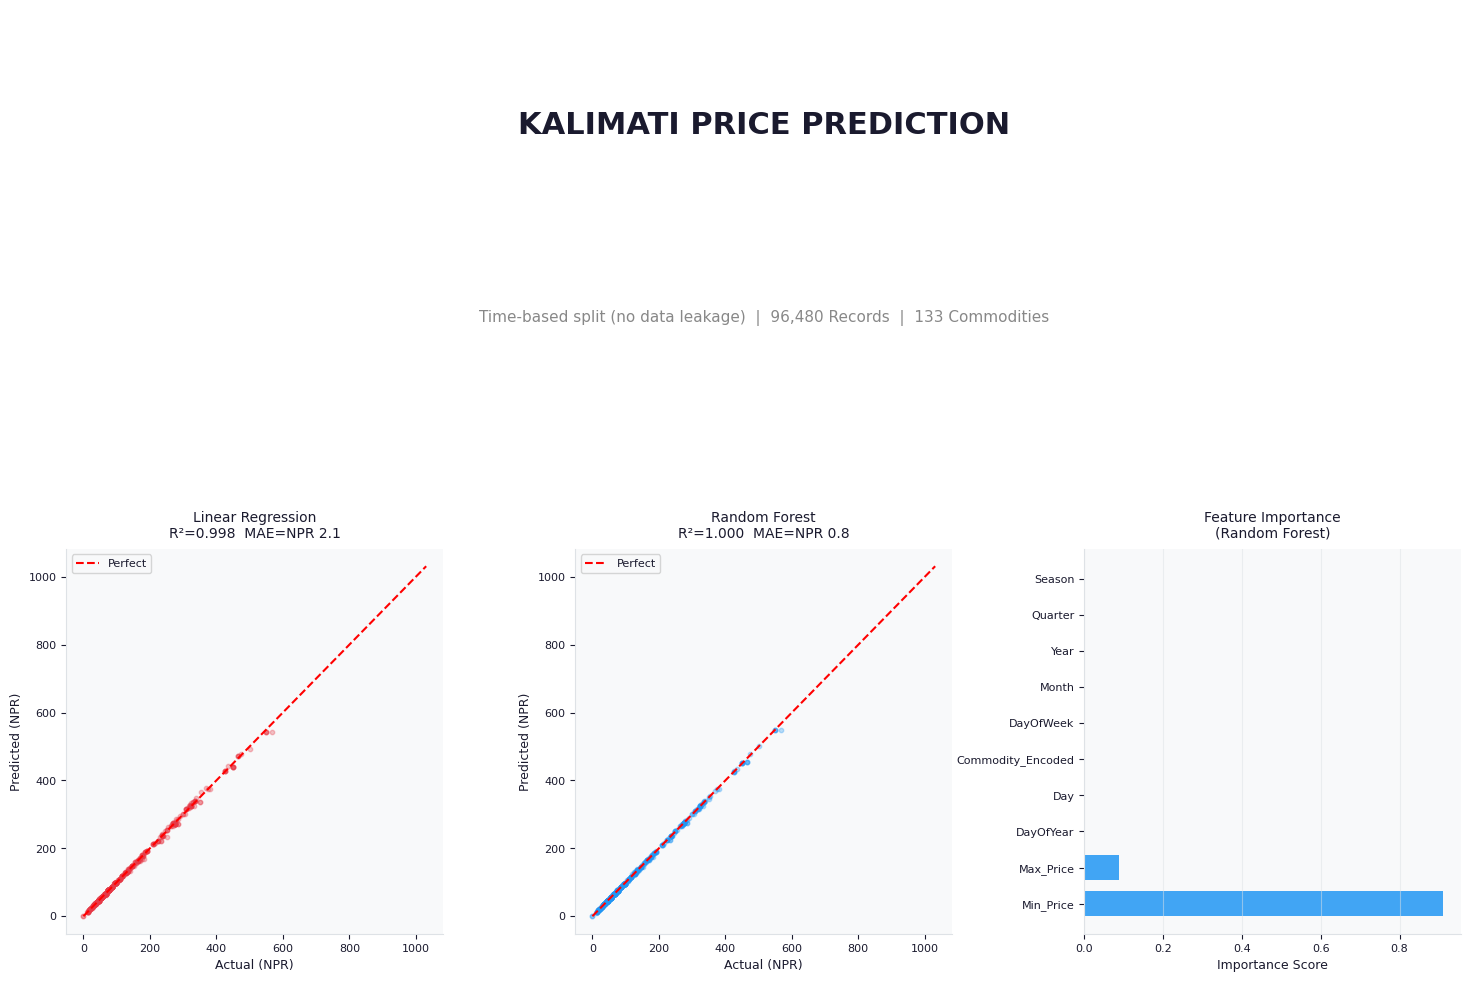

In [43]:
print("KALIMATI PRICE PREDICTION")
 
# 1. Load
df = load_data(DATA_PATH)
 
# 2. Clean
df = clean_columns(df, ['Min_Price', 'Max_Price', 'Average_Price'])
 
# 3. Engineer features
df = engineer_features(df)
 
# 4. Encode commodities
df, le = encode_commodities(df)
 
# 5. Time-based split (no data leakage)
train, test = time_based_split(df, SPIT_DATE)
 
FEATURES = ['Commodity_Encoded', 'Year', 'Month', 'Day',
            'DayOfWeek', 'DayOfYear', 'Quarter', 'Season',
            'Min_Price', 'Max_Price']
TARGET = 'Average_Price'
 
X_train, y_train = train[FEATURES], train[TARGET]
X_test,  y_test  = test[FEATURES],  test[TARGET]
 
# 6. Train models
print("\n── TRAINING MODELS... ──")
lr = LinearRegression()
lr.fit(X_train, y_train)
print(" Linear Regression trained")
 
rf = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)
print(" Random Forest trained")
 
# 7. Evaluate
y_pred_lr = lr.predict(X_test)
y_pred_rf = rf.predict(X_test)
 
mae_lr, rmse_lr, r2_lr = evaluate_model("LINEAR REGRESSION", y_test, y_pred_lr)
mae_rf, rmse_rf, r2_rf = evaluate_model("RANDOM FOREST",     y_test, y_pred_rf)
 
# 8. Feature importance
importance = pd.DataFrame({
    'Feature': FEATURES,
    'Importance': rf.feature_importances_
}).sort_values('Importance', ascending=False)
 
print("\n── FEATURE IMPORTANCE ──")
for _, row in importance.iterrows():
    bar = "█" * int(row['Importance'] * 50)
    print(f"   {row['Feature']:<25} {bar} {row['Importance']:.4f}")
 
# 9. Sample prediction
predict_commodity("Tomato Big(Nepali)", 2023, 6, 1, lr, rf, df, le, FEATURES)
 
# 10. Plot
plot_results(y_test, y_pred_lr, y_pred_rf, importance,
             r2_lr, mae_lr, r2_rf, mae_rf)
 
# 11. Save predictions
results = pd.DataFrame({
    'Actual':       y_test.values,
    'LR_Predicted': y_pred_lr,
    'RF_Predicted': y_pred_rf,
    'LR_Error':     abs(y_test.values - y_pred_lr),
    'RF_Error':     abs(y_test.values - y_pred_rf)
})
results.to_csv('kalimati_predictions.csv', index=False)
print(" Predictions saved!")